In [1]:
import pandas as pd
import numpy as np
import hnswlib as hl
import hnsw_benchmark2 as bm
import farhest_point_order as fp
import matplotlib.pyplot as plt
import os

In [2]:
dataset_name = "arguana"
corpus_filename = dataset_name + "_corpus_lid"
corpus_input_path = os.path.join("..\\data\\", corpus_filename + ".json")
df_corpus = pd.read_json(corpus_input_path, orient="records", lines=True)

query_filename = dataset_name + "_query"
query_input_path = os.path.join("..\\data\\", query_filename + ".json")
df_query = pd.read_json(query_input_path, orient="records", lines=True)

In [3]:
print("Corpus data")
# print(df_corpus)
# print(df_corpus.keys)
corpus_vectors = np.asarray([np.asarray(v) for v in df_corpus.vectors], dtype=np.float32)
print(corpus_vectors.shape)

print("Query data")
# print(df_query)
# print(df_query.keys)
query_vectors = np.asarray([np.asarray(v) for v in df_query.vectors], dtype=np.float32)
print(query_vectors.shape)


Corpus data
(8674, 384)
Query data
(1406, 384)


In [4]:
# KNN számítás minden query vectorra - TESZT
k = 10
scores = query_vectors @ corpus_vectors.T

topk = np.argpartition(
    -scores,
    kth=k - 1,
    axis=1,
)[:, :k]

# Optional: sort those k results by actual score
rows = np.arange(len(df_query.vectors))[:, None]
order = np.argsort(-scores[rows, topk], axis=1)

knn_matrix = np.take_along_axis(topk, order, axis=1)

print(knn_matrix.shape)
# for i in knn_matrix[0]:
#     print(f"{i:4d} - dist: {hnswbm.KNN.euclidian_distance(df_query.vectors[0], df_corpus.vectors[i]):.4f}")

(1406, 10)


In [5]:
# HNSW konstruálás - TESZT
hnsw = hl.Index(space             = 'ip',
                dim               = corpus_vectors.shape[1])
hnsw.init_index(max_elements      = corpus_vectors.shape[0],
                M                 = 16,
                ef_construction   = 128)
hnsw.add_items(data               = corpus_vectors)

In [6]:
# HNSW futtatás - TESZT
hnsw.set_ef(10)

hnsw_indicies, _ = hnsw.knn_query(query_vectors, k=10)

print(hnsw_indicies.shape)

(1406, 10)


In [7]:
# Recall számítás - TESZT
recalls = []

for R_A, R_E in zip(hnsw_indicies, knn_matrix):
    recalls.append(
        len(set(R_A) & set(R_E)) / len(R_E)
    )

print(np.min(recalls))
print(np.mean(recalls))
print(np.max(recalls))

0.0
0.9280227596017071
1.0


In [8]:
# HNSW benchmark - Random beszúrás
bm_random = bm.HNSW_benchmark(data=df_corpus.vectors)
recalls_random = bm_random.run(qs=df_query.vectors, ef_search=10)

print(f"Minimum recall: {np.min(recalls_random):.4f}")
print(f"Average recall: {np.mean(recalls_random):.4f}")
print(f"Maximum recall: {np.max(recalls_random):.4f}")

# plt.figure(figsize=(8, 5))
# plt.hist(recalls_random, bins=10, edgecolor="black", alpha=0.75)
# plt.title("Distribution of recall values")
# plt.xlabel("Recall")
# plt.ylabel("Count")
# plt.grid(axis="y", alpha=0.3)
# plt.ylim(0, len(df_query.vectors))
# plt.show()

Minimum recall: 0.0000
Average recall: 0.9262
Maximum recall: 1.0000


In [27]:
# HNSW benchmark - LID szerint csökkenő
lid_desc_indices = np.argsort(df_corpus.LID, descending=True)
bm_lid_desc = bm.HNSW_benchmark(data=[df_corpus.vectors[i] for i in lid_desc_indices])
recalls_lid_desc = bm_lid_desc.run(qs=df_query.vectors, ef_search=10)

print(f"Minimum recall: {np.min(recalls_lid_desc):.4f}")
print(f"Average recall: {np.mean(recalls_lid_desc):.4f}")
print(f"Maximum recall: {np.max(recalls_lid_desc):.4f}")

# plt.figure(figsize=(8, 5))
# plt.hist(recalls_lid_desc, bins=10, edgecolor="black", alpha=0.75)
# plt.title("Distribution of recall values")
# plt.xlabel("Recall")
# plt.ylabel("Count")
# plt.grid(axis="y", alpha=0.3)
# plt.ylim(0, len(df_query.vectors))
# plt.show()

Minimum recall: 0.0000
Average recall: 0.9524
Maximum recall: 1.0000


In [10]:
# HNSW benchmark - LID szerint növekvő
lid_asc_indices = np.argsort(df_corpus.LID, descending=False)
bm_lid_asc = bm.HNSW_benchmark(data=[df_corpus.vectors[i] for i in lid_asc_indices])
recalls_lid_asc = bm_lid_asc.run(qs=df_query.vectors, ef_search=10)

print(f"Minimum recall: {np.min(recalls_lid_asc):.4f}")
print(f"Average recall: {np.mean(recalls_lid_asc):.4f}")
print(f"Maximum recall: {np.max(recalls_lid_asc):.4f}")

# plt.figure(figsize=(8, 5))
# plt.hist(recalls_lid_asc, bins=10, edgecolor="black", alpha=0.75)
# plt.title("Distribution of recall values")
# plt.xlabel("Recall")
# plt.ylabel("Count")
# plt.grid(axis="y", alpha=0.3)
# plt.ylim(0, len(df_query.vectors))
# plt.show()

Minimum recall: 0.0000
Average recall: 0.9377
Maximum recall: 1.0000


In [ ]:
# Farthest points igazi számítása
df_farthest_score = fp.farthest_point_order(corpus_vectors)

dataset_name = "arguana"
corpus_filename = dataset_name + "_corpus_lid_fps"
corpus_output_path = os.path.join("..\\data\\", corpus_filename + ".json")

# print(df_corpus.keys())
# print(len(df_farthest_score))
# df_farthest_score = np.pad(
#     df_farthest_score,
#     (0, len(df_corpus) - len(df_farthest_score)),
#     mode="constant",
#     constant_values=0,
# )
# print(len(df_farthest_score))
df_corpus = df_corpus.assign(fp_score=df_farthest_score)
# df_corpus.drop(columns=["fp_score"], inplace=True)
print(df_corpus.keys())
df_corpus.to_json(corpus_output_path, orient="records", lines=True)

Index(['vectors', 'LID'], dtype='str')
8674
8674
Index(['vectors', 'LID', 'fp_score'], dtype='str')


In [68]:
# print(np.min(df_farthest_score))
print(df_farthest_score[:10])

df_farthest_indices = np.argsort(df_farthest_score, descending=True)

print(df_farthest_indices[:10])

for i, p_i in enumerate(df_farthest_indices[:6]):
    for j in range(0, i):
        print(f"{i+1}.{j+1} {p_i:4d}({df_farthest_score[p_i]}) - {df_farthest_indices[j]:4d}({df_farthest_score[df_farthest_indices[j]]}): {np.sqrt(fp.squared_distance(corpus_vectors[p_i], corpus_vectors[df_farthest_indices[j]]))}")



[4211 7935 6365 4032 5868 3531 4113 1152 3057 2741]
[5189 6567 5347 1745 1484 1910 7480 6348 4901 4542]
2.1 6567(8672) - 5189(8673): 0.6667945384979248
3.1 5347(8671) - 5189(8673): 0.6821629405021667
3.2 5347(8671) - 6567(8672): 0.6513612866401672
4.1 1745(8670) - 5189(8673): 0.6473392248153687
4.2 1745(8670) - 6567(8672): 0.6799436807632446
4.3 1745(8670) - 5347(8671): 0.6327104568481445
5.1 1484(8669) - 5189(8673): 0.6633297204971313
5.2 1484(8669) - 6567(8672): 0.6002560257911682
5.3 1484(8669) - 5347(8671): 0.6048290729522705
5.4 1484(8669) - 1745(8670): 0.630098283290863
6.1 1910(8668) - 5189(8673): 0.6912707686424255
6.2 1910(8668) - 6567(8672): 0.6433297991752625
6.3 1910(8668) - 5347(8671): 0.6726803779602051
6.4 1910(8668) - 1745(8670): 0.6465072631835938
6.5 1910(8668) - 1484(8669): 0.6752253770828247


Eredeti pontok listája:
[(-0.3845711689488433, 0.23578892269086948), (0.3947012009249208, 0.0394886514895044), (0.582840301399079, 0.0685223317604783), (-0.4851837313329022, 0.3562974734881051), (0.037288278446284795, 0.03566737792816991), (-0.27733070198581866, 0.2146350678105358), (-0.16147007621891607, 0.15019483184783936), (-0.4057281744990126, -0.019080053490502537), (-0.24766522743182695, -0.013835495814236622), (-0.3142614994099949, 0.10719632444005793)]
0(10.0) - nan
1(9.0) - 1.1061147619887548
2(8.0) - 0.5797749773022873
3(7.0) - 0.6075077654670556
4(6.0) - 0.43816283921201654
5(5.0) - 0.5960062539003309


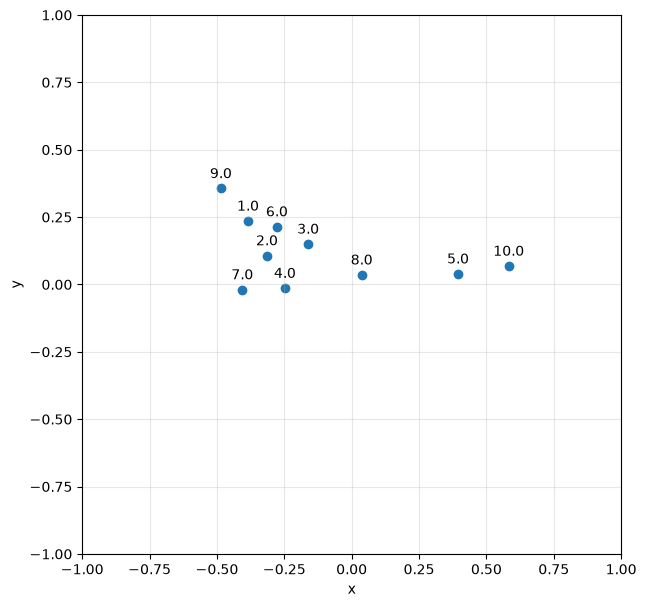

In [36]:
# farthest point
values = lambda points, _neighbor_count: (fp.calculate_farthest_values(points), None)

# 1. Legeneráljuk és eltároljuk a pontokat
# pts = fp.generate_points(4, "Legtávolabbi párok")
pts = fp.generate_points(10, "Két klaszter")

# 2. Kiszámoljuk az értékeket
scores, _ = values(pts, 2)

# 3. Kiírjuk a nyers eredeti pontlistát
print("Eredeti pontok listája:")
print(pts)


# df_farthest_indices = np.argsort(scores, descending=True)

# for i, p_i in enumerate(df_farthest_indices[:6]):
#     dists = [np.sqrt(fp.squared_distance(pts[p_i], pts[df_farthest_indices[j]])) for j in range(0, i)]
#     print(f"{i}({scores[p_i]}) - {np.mean(dists)}")

# for i, p_i in enumerate(df_farthest_indices[:6]):
#     for j in range(0, i):
#         print(f"{i+1}.{j+1} {p_i:4d}({scores[p_i]}) - {df_farthest_indices[j]:4d}({scores[df_farthest_indices[j]]}): {np.sqrt(fp.squared_distance(pts[p_i], pts[df_farthest_indices[j]]))}")

fig, ax = plt.subplots(figsize=(7, 7))
pts = np.asarray(pts)
ax.scatter(pts[:, 0], pts[:, 1])

for x, y, score in zip(pts[:, 0], pts[:, 1], scores):
    ax.annotate(f"{score}", (x, y), xytext=(0, 5),
                textcoords="offset points", ha="center", va="bottom")

ax.set(xlim=(-1, 1), ylim=(-1, 1), xlabel="x", ylabel="y")
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
plt.show()

In [ ]:
# LID :)
df_lid = bm.calculate_lid(df_corpus.vectors)

print(df_lid[:10])

In [ ]:
# LID - TESZT
# KNN számítás minden pontra
k = 100
data = np.asarray(df_corpus.vectors.tolist(), dtype=np.float32)
scores = data @ data.T

# Assign the same ID to identical vectors, then exclude them from each row.
_, vector_ids = np.unique(data, axis=0, return_inverse=True)
for row, vector_id in enumerate(vector_ids):
    scores[row, vector_ids == vector_id] = -np.inf

topk = np.argpartition(-scores, kth=k - 1, axis=1)[:, :k]

rows = np.arange(len(data))[:, None]
order = np.argsort(-scores[rows, topk], axis=1)

knn_matrix = np.take_along_axis(topk, order, axis=1)

# print(knn_matrix[14][:10])
print(knn_matrix[14][-10:])
# for i in knn_matrix[14][:10]:
for i in knn_matrix[14][-10:]:
    print(bm.euclidian_distance(corpus_vectors[i], corpus_vectors[14]))


knn = bm.KNN(corpus_vectors)
lid = knn.get_KNN(corpus_vectors[14], k)
# print(lid[:10])
print(lid[-10:])
# for i in lid[:10]:
for i in lid[-10:]:
    print(bm.euclidian_distance(corpus_vectors[i], corpus_vectors[14]))